### Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import scipy.io
import matplotlib.gridspec as gridspec
import os
import math

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

[device] cuda


In [3]:
pval           = 0.10
beta           = 5
epochs         = 10
batch_size     = 16
bottleneck_dim = 25
lr             = 1e-4
dataset        = "landscapes" # landscapes, mnist, or cifar10

### Dataset

In [4]:
class AndrewNgLandscape(Dataset):
    def __init__(self):
        # IMAGES.mat was taken from Andrew Ng's course, which is also where we're getting notes for the Sparse Autoencoder
        # Obtained here: https://github.com/fanfeng2015/Sparse-Autoencoder
        mat           = scipy.io.loadmat('IMAGES.mat')

        self.wh_landscapes = torch.Tensor(mat['IMAGES']).permute(2, 0, 1) # Shape: (num_images, height, width)
        self.num_samples   = 10000
        self.patch_size    = 8
        self.image_height  = self.wh_landscapes.shape[1]
        self.image_width   = self.wh_landscapes.shape[2]

        self.grid_h = self.image_height // self.patch_size
        self.grid_w = self.image_width // self.patch_size

        self.patches = []
        for _ in range(self.num_samples):
            image_idx = torch.randint(0, self.wh_landscapes.shape[0], (1,)).item()
            grid_x = torch.randint(0, self.grid_h, (1,)).item()
            grid_y = torch.randint(0, self.grid_w, (1,)).item()

            x_start = grid_x * self.patch_size
            y_start = grid_y * self.patch_size

            patch = self.wh_landscapes[
                image_idx,
                x_start : x_start + self.patch_size,
                y_start : y_start + self.patch_size,
            ]
            self.patches.append(patch.flatten())

        self.patches = torch.stack(self.patches)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.patches[idx], 0

In [5]:
def get_data_loader(dataset: str) -> DataLoader:
    if dataset == "landscapes":
        landscape_dataset = AndrewNgLandscape()
        return DataLoader(landscape_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

    elif dataset == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            lambda x: x.flatten(),
        ])
        mnist_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
        return DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

    elif dataset == "cifar10":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Grayscale(num_output_channels=1),
            transforms.Normalize((0.5,), (0.5,)),
            lambda x: x.flatten()
        ])
        cifar10_dataset = datasets.CIFAR10('../data', train=True, download=True, transform=transform)
        return DataLoader(cifar10_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)


In [6]:
def get_flattened_size(dataset: str) -> int:
    if dataset == "landscapes":
        return 8 * 8

    elif dataset == "mnist":
        return 28 * 28

    elif dataset == "cifar10":
        return 32 * 32

In [7]:
data_loader = get_data_loader(dataset)

### Autoencoders

In [8]:
class Autoencoder(nn.Module):
    def __init__(
        self,
        dim: tuple
    ) -> None:
        super().__init__()

        self.input_dim, self.bottleneck_dim = dim

        self.encoder = nn.Linear(self.input_dim, self.bottleneck_dim)
        self.sigmoid = nn.Sigmoid()
        self.decoder = nn.Linear(self.bottleneck_dim, self.input_dim)

    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:
        if x.ndim == 1:
            x = x.unsqueeze(0)

        z1 = self.encoder(x)
        a1 = self.sigmoid(z1)
        z2 = self.decoder(a1)

        return z2, a1.mean(dim=0)

In [9]:
class FC_WTA_Autoencoder(nn.Module):
    def __init__(
        self,
        dim: tuple,
        k: float,
    ) -> None:
        super().__init__()

        self.input_dim, self.bottleneck_dim = dim
        self.k = k

        self.encoder    = nn.Linear(self.input_dim, self.bottleneck_dim)
        self.relu       = nn.ReLU()
        self.decoder    = nn.Linear(self.bottleneck_dim, self.input_dim)

    def forward(
        self,
        x: torch.Tensor
    ) -> torch.Tensor:
        if x.ndim == 1:
            x = x.unsqueeze(0)

        z1 = self.encoder(x)
        a1 = self.relu(z1)

        _, a1_topk_idx = torch.topk(a1, int(self.bottleneck_dim * self.k), dim=1)
        a1_wta_mask = torch.zeros_like(a1)
        a1_wta_mask.scatter_(1, a1_topk_idx, 1)

        a1_wta = a1 * a1_wta_mask
        z2 = self.decoder(a1_wta)

        return z2

In [10]:
class SparseMSELoss(nn.Module):
    def __init__(
        self,
        beta: float = 1.0
    ) -> None:
        super().__init__()
        self.mse_loss = nn.MSELoss()
        self.beta = beta

    def forward(
        self,
        x_recon: torch.Tensor,
        x_original: torch.Tensor,
        p: torch.Tensor,
        p_hat: torch.Tensor,
    ) -> torch.Tensor:
        mse_loss = self.mse_loss(x_recon, x_original)

        p     = torch.clamp(p,     min=1e-7, max=1 - 1e-7)
        p_hat = torch.clamp(p_hat, min=1e-7, max=1 - 1e-7)

        kl_divergence = torch.sum(
            p       * (torch.log(p)     - torch.log(p_hat)) +
            (1 - p) * (torch.log(1 - p) - torch.log(1 - p_hat))
        )

        total_loss = mse_loss + self.beta * kl_divergence
        return total_loss

In [11]:
input_dim = get_flattened_size(dataset)

normal_autoencoder = Autoencoder(dim=(input_dim, bottleneck_dim)).to(device)
normal_criterion   = nn.MSELoss()
normal_optimizer   = torch.optim.SGD(normal_autoencoder.parameters(), lr=lr, momentum=True)

sparse_autoencoder = Autoencoder(dim=(input_dim, bottleneck_dim)).to(device)
sparse_criterion   = SparseMSELoss(beta=beta)
sparse_optimizer   = torch.optim.SGD(sparse_autoencoder.parameters(), lr=lr, momentum=True)

fc_wta_autoencoder = FC_WTA_Autoencoder(dim=(input_dim, bottleneck_dim), k=pval).to(device)
fc_wta_criterion   = nn.MSELoss()
fc_wta_optimizer   = torch.optim.SGD(fc_wta_autoencoder.parameters(), lr=lr, momentum=True)

### Training

In [12]:
normal_losses = []
sparse_losses = []
fc_wta_losses = []

normal_autoencoder.train()
sparse_autoencoder.train()
fc_wta_autoencoder.train()
epochbar = tqdm(range(1, epochs + 1), desc="Epochs")

p = torch.tensor(pval)
for epoch in epochbar:
    normal_epoch_loss = 0.0
    sparse_epoch_loss = 0.0
    fc_wta_epoch_loss = 0.0
    for batch_inputs, _ in data_loader:
        batch_inputs = batch_inputs.to(device)
        normal_optimizer.zero_grad()
        sparse_optimizer.zero_grad()
        fc_wta_optimizer.zero_grad()

        normal_x_recon, _     = normal_autoencoder(batch_inputs)
        sparse_x_recon, p_hat = sparse_autoencoder(batch_inputs)
        fc_wta_x_recon        = fc_wta_autoencoder(batch_inputs)

        normal_loss = normal_criterion(normal_x_recon, batch_inputs)
        sparse_loss = sparse_criterion(sparse_x_recon, batch_inputs, p, p_hat)
        fc_wta_loss = fc_wta_criterion(fc_wta_x_recon, batch_inputs)

        normal_loss.backward()
        sparse_loss.backward()
        fc_wta_loss.backward()

        normal_optimizer.step()
        sparse_optimizer.step()
        fc_wta_optimizer.step()

        normal_batch_loss = normal_loss.item()
        sparse_batch_loss = sparse_loss.item()
        fc_wta_epoch_loss = fc_wta_loss.item()

        normal_epoch_loss += normal_batch_loss * batch_inputs.size(0)
        sparse_epoch_loss += sparse_batch_loss * batch_inputs.size(0)
        fc_wta_epoch_loss += fc_wta_epoch_loss * batch_inputs.size(0)

        epochbar.set_postfix({
            "normal_loss": f"{normal_batch_loss:.4f}",
            "sparse_loss": f"{sparse_batch_loss:.4f}",
            "fc_wta_loss": f"{fc_wta_epoch_loss:.4f}"
        })

    normal_epoch_loss /= len(data_loader.dataset)
    sparse_epoch_loss /= len(data_loader.dataset)
    fc_wta_epoch_loss /= len(data_loader.dataset)

    normal_losses.append(normal_epoch_loss)
    sparse_losses.append(sparse_epoch_loss)
    fc_wta_losses.append(fc_wta_epoch_loss)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

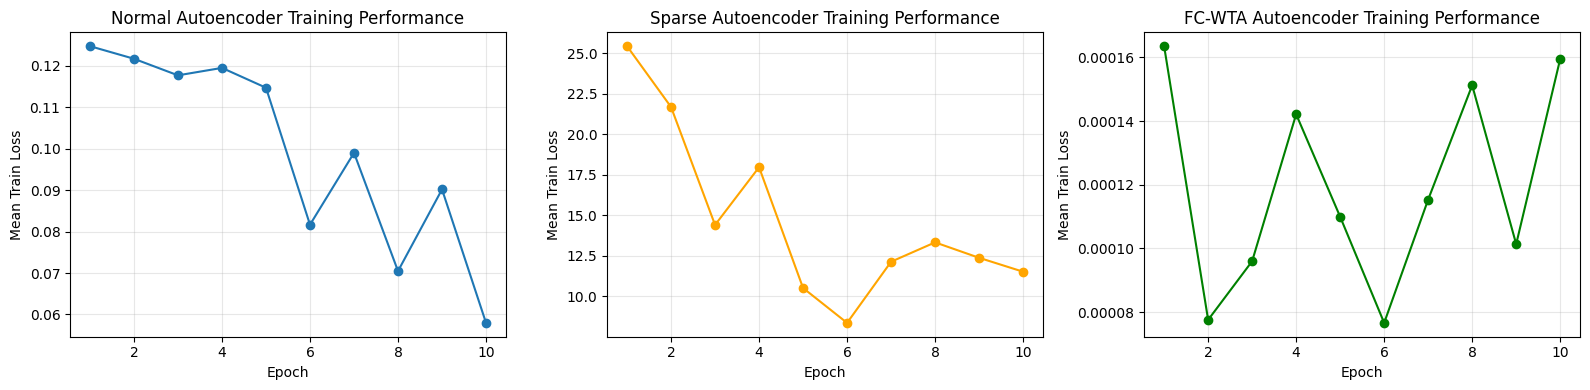

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1, epochs + 1), normal_losses, "o-")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Train Loss")
axes[0].set_title("Normal Autoencoder Training Performance")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), sparse_losses, "o-", color='orange')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Train Loss")
axes[1].set_title("Sparse Autoencoder Training Performance")
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, epochs + 1), fc_wta_losses, "o-", color='green')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Train Loss")
axes[2].set_title("FC-WTA Autoencoder Training Performance")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization

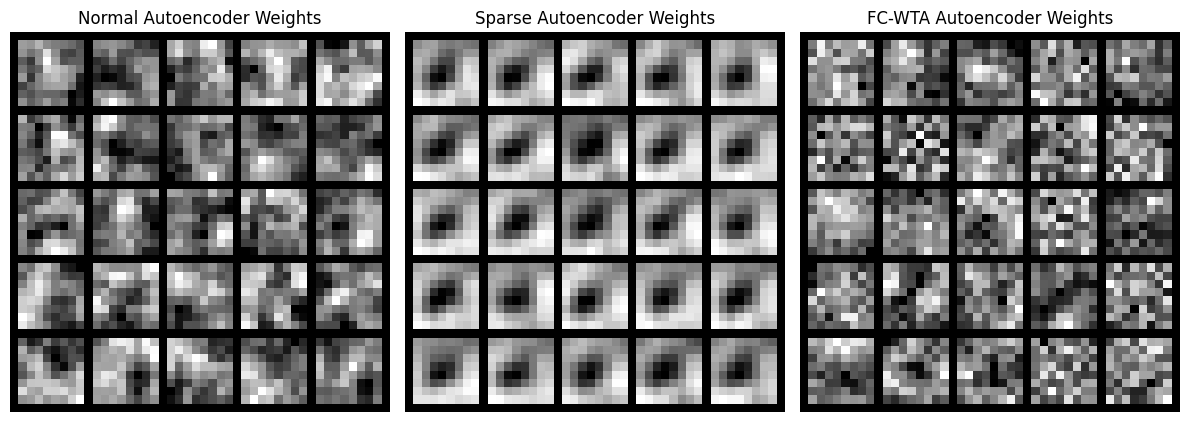

In [14]:
def maximal_activation_normalize(W):
    return W / torch.sqrt(torch.sum(W**2, dim=1, keepdim=True) + 1e-8)

W_enc_normal = maximal_activation_normalize(normal_autoencoder.encoder.weight.detach().cpu())
W_enc_sparse = maximal_activation_normalize(sparse_autoencoder.encoder.weight.detach().cpu())
W_enc_fc_wta = maximal_activation_normalize(fc_wta_autoencoder.encoder.weight.detach().cpu())

kernels_normal = W_enc_normal.reshape(-1, 1, int(math.sqrt(input_dim)), int(math.sqrt(input_dim)))
kernels_sparse = W_enc_sparse.reshape(-1, 1, int(math.sqrt(input_dim)), int(math.sqrt(input_dim)))
kernels_fc_wta = W_enc_fc_wta.reshape(-1, 1, int(math.sqrt(input_dim)), int(math.sqrt(input_dim)))

grid_normal = make_grid(kernels_normal, nrow=5, normalize=True, scale_each=True, padding=1)
grid_sparse = make_grid(kernels_sparse, nrow=5, normalize=True, scale_each=True, padding=1)
grid_fc_wta = make_grid(kernels_fc_wta, nrow=5, normalize=True, scale_each=True, padding=1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(grid_normal.permute(1, 2, 0))
plt.axis('off')
plt.title('Normal Autoencoder Weights')

plt.subplot(1, 3, 2)
plt.imshow(grid_sparse.permute(1, 2, 0))
plt.axis('off')
plt.title('Sparse Autoencoder Weights')

plt.subplot(1, 3, 3)
plt.imshow(grid_fc_wta.permute(1, 2, 0))
plt.axis('off')
plt.title('FC-WTA Autoencoder Weights')

plt.tight_layout()
plt.show()